# **Подгоовка** данных по территории

## 1. Получение кварталов

### 1.1. Получение данных из **OpenStreetMap**. 
Этот шаг можно пропустить, если данные уже существуют.

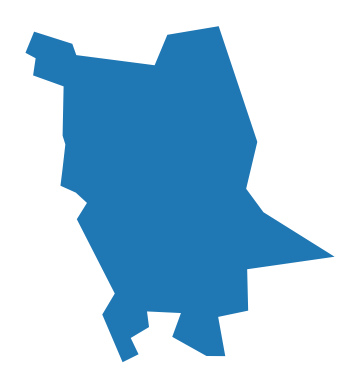

In [1]:
import osmnx as ox

boundaries = ox.geocode_to_gdf('Сватово, Сватовская городская община')
boundaries.plot().set_axis_off()

In [2]:
bc_tags = {
    'roads': {
      "highway": ["construction","crossing","living_street","motorway","motorway_link","motorway_junction","pedestrian","primary","primary_link","raceway","residential","road","secondary","secondary_link","services","tertiary","tertiary_link","track","trunk","trunk_link","turning_circle","turning_loop","unclassified",],
      "service": ["living_street", "emergency_access"]
    },
    'railways': {
      "railway": "rail"
    },
    'water': {
      'riverbank':True,
      'reservoir':True,
      'basin':True,
      'dock':True,
      'canal':True,
      'pond':True,
      'natural':['water','bay'],
      'waterway':['river','canal','ditch'],
      'landuse':'basin',
      'water': 'lake'
    }
}

In [3]:
water = ox.features_from_polygon(boundaries.union_all(), bc_tags['water'])
roads = ox.features_from_polygon(boundaries.union_all(), bc_tags['roads'])
railways = ox.features_from_polygon(boundaries.union_all(), bc_tags['railways'])

In [4]:
water = water[water.geom_type.isin(['Polygon', 'MultiPolygon', 'LineString', 'MultiLineString'])].copy()
roads = roads[roads.geom_type.isin(['LineString', 'MultiLineString'])].copy()
railways = railways[railways.geom_type.isin(['LineString', 'MultiLineString'])].copy()

In [5]:
crs = boundaries.estimate_utm_crs()

for gdf in [water, roads, railways, boundaries]:
  gdf.to_crs(crs, inplace=True)

### 1.2. Предварительная обработка входной геометрии

Этот шаг можно пропустить, если входная геометрия уже отсортирована как линии, многоугольники и границы.

In [6]:
roads = roads.reset_index(drop=True)
railways = railways.reset_index(drop=True)
water = water.reset_index(drop=True)

In [7]:
from blocksnet.blocks.cutting import preprocess_urban_objects, cut_urban_blocks

lines, polygons = preprocess_urban_objects(roads, railways, water)

2025-12-09 13:56:16.526 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:44 - Checking roads schema
2025-12-09 13:56:16.531 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:51 - Checking railways schema
2025-12-09 13:56:16.535 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:58 - Checking water schema


### 1.3. **Нарезка** городских кварталов

2025-12-09 13:56:16.545 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:51 - Checking boundaries schema
2025-12-09 13:56:16.550 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:55 - Checking line objects schema
2025-12-09 13:56:16.556 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:62 - Checking polygon objects schema
2025-12-09 13:56:16.561 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:69 - Checking buildings schema
2025-12-09 13:56:16.561 | WARNING  | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:71 - Creating empty buildings
2025-12-09 13:56:16.584 | SUCCESS  | blocksnet.blocks.cutting.processing.core:cut_urban_blocks:26 - 157 blocks are successfully cut


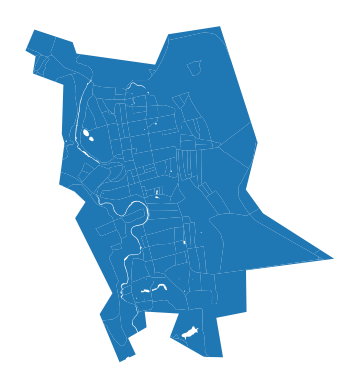

In [8]:
blocks = cut_urban_blocks(boundaries, lines, polygons)
blocks.plot().set_axis_off()

___


## 2. Назначение **землепользования**


### 2.1. Получение данных из OpenStreetMap

Этот шаг можно пропустить, если слой функциональных зон уже получен из государственных источников.

In [9]:
import osmnx as ox

functional_zones = ox.features_from_polygon(boundaries.to_crs(4326).union_all(), tags={'landuse': True})

In [10]:
functional_zones = functional_zones.reset_index(drop=True)[['geometry','landuse']].rename(columns={'landuse': 'functional_zone'})
functional_zones = functional_zones.to_crs(crs)
functional_zones.head()

,geometry,functional_zone
0,"POLYGON ((440935.821 5472820.764, 440926.523 5...",forest
1,"POLYGON ((436141.427 5474925.165, 436167.2 547...",forest
2,"POLYGON ((436262.318 5476188.359, 436284.951 5...",forest
3,"POLYGON ((436708.022 5472986.797, 436753.541 5...",forest
4,"POLYGON ((436553.288 5473604.049, 436608.313 5...",cemetery



### 2.2. Указание правил

Правила определяют, как столбец `functional_zone` будет отображаться в `LandUse`.

In [11]:
from blocksnet.enums import LandUse

rules = {
  'commercial': LandUse.BUSINESS,
  'industrial': LandUse.INDUSTRIAL,
  'cemetery': LandUse.SPECIAL,
  'garages': LandUse.INDUSTRIAL,
  'residential': LandUse.RESIDENTIAL,
  'retail': LandUse.BUSINESS,
  'grass': LandUse.RECREATION,
  'farmland': LandUse.AGRICULTURE,
  'construction': LandUse.SPECIAL,
  'brownfield': LandUse.INDUSTRIAL,
  'forest': LandUse.RECREATION,
  'recreation_ground': LandUse.RECREATION,
  'religious': LandUse.SPECIAL,
  'flowerbed': LandUse.RECREATION,
  'military': LandUse.SPECIAL,
  'landfill': LandUse.TRANSPORT
}

### 2.3. Назначение земплепользования 

In [12]:
from blocksnet.blocks.assignment import assign_land_use

blocks = assign_land_use(blocks, functional_zones.reset_index(drop=True).rename(columns={'landuse': 'functional_zone'}), rules)

2025-12-09 13:56:16.727 | WARNING  | blocksnet.blocks.assignment.land_use:_preprocess_functional_zones:17 - Functional zones not in rules: reservoir, farmyard, orchard, meadow


In [13]:
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((442718.951 5471710.302, 442745.301 5...",0.0,0.0,0.394623,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.394623
1,"POLYGON ((442745.301 5471695.335, 442718.951 5...",0.0,0.0,0.039570,0.00000,0.0,0.0,0.906288,LandUse.AGRICULTURE,0.906288
2,"POLYGON ((442580.521 5471789.381, 442718.951 5...",0.0,0.0,0.297516,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.297516
3,"POLYGON ((442505.529 5471832.217, 442580.521 5...",0.0,0.0,0.040294,0.09687,0.0,0.0,0.492953,LandUse.AGRICULTURE,0.492953
4,"POLYGON ((442505.529 5471832.217, 442243.731 5...",0.0,0.0,0.000000,0.00000,0.0,0.0,0.906280,LandUse.AGRICULTURE,0.906280


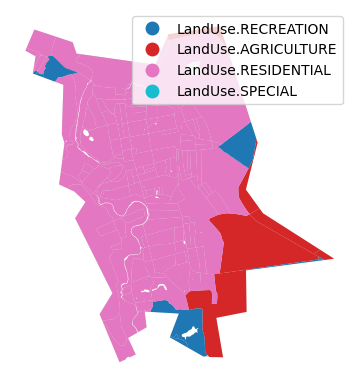

In [14]:
ax = blocks.plot(color='#ddd')
blocks.plot(column='land_use', legend=True, ax=ax).set_axis_off()

___

## 3. Расчет матрицы доступности

Существует несколько способов определения пространственных связей между городскими кварталами:
- **Матрица доступности** - матрица `n ^ 2`, которая определяет время в пути между центроидами городских кварталов в минутах.
- **Матрица расстояний** - матрица `n ^ 2`, которая определяет евклидово расстояние между центроидами городских кварталов в метрах.
- **График смежности** - график с `n` узлами. Каждое ребро этого графика указывает на пространственную смежность двух городских кварталов.

В этом примере **матрица доступности** будет рассчитана с использованием библиотеки IduEdu.

### 3.1. Построение интермодальных графов

Существует несколько типов городских графов для моделирования городской сети:
- **walk** - пешеходная сеть.
- **drive** - сеть личного транспорта.
- **интермодальная** - сеть пешеходного и общественного транспорта.

В этом примере будет построен **интермодальный** график, но в целом это зависит от результатов исследования.

In [19]:
from blocksnet.relations import get_accessibility_graph

graph = get_accessibility_graph(boundaries, 'intermodal')

2025-12-09 13:56:56.232 | INFO     | iduedu.modules.drive_walk_builder:get_walk_graph:217 - Downloading walk graph from OSM, it may take a while for large territory ...


Calculating the weights of the walk graph:   0%|          | 0/1944 [00:00<?, ?it/s]

2025-12-09 13:56:57.358 | WARNING  | iduedu.modules.public_transport_builder:get_all_public_transport_graph:259 - No routes found for public transport.
2025-12-09 13:56:57.444 | WARNING  | iduedu.modules.intermodal_builder:get_intermodal_graph:98 - Public trasport graph is empty! Returning only walk graph.


### 3.2. Вычисление матрицы доступности

In [20]:
from blocksnet.relations import calculate_accessibility_matrix

acc_mx = calculate_accessibility_matrix(blocks, graph)

In [21]:
acc_mx.head()

/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,0,1,2,3,4,5,6,7,8,9,...,147,148,149,150,151,152,153,154,155,156
0,0.000000,6.363281,5.750000,27.203125,18.453125,45.65625,46.093750,52.93750,78.8750,75.87500,...,110.1875,87.3750,79.1250,92.0000,104.6875,101.8750,125.8125,127.8125,126.3750,104.6875
1,4.015625,0.000000,0.000000,23.687500,14.945312,42.15625,42.593750,49.37500,75.4375,72.31250,...,106.6250,83.8125,80.5625,88.5000,101.1250,98.3750,122.2500,124.3125,122.8750,101.1875
2,3.398438,0.000000,0.000000,23.078125,14.328125,41.53125,41.968750,48.78125,74.8125,71.68750,...,106.0000,83.1875,79.9375,87.8750,100.5000,97.7500,121.6250,123.6875,122.2500,100.5625
3,24.859375,23.687500,23.078125,0.000000,11.531250,28.81250,29.218750,36.03125,62.0625,58.96875,...,93.3125,70.4375,67.4375,75.1250,87.8125,85.0000,108.9375,110.9375,109.5000,87.8750
4,16.109375,14.945312,14.328125,11.531250,0.000000,30.00000,30.421875,37.21875,63.2500,60.15625,...,94.4375,71.6250,68.5625,76.3125,89.0000,86.1875,110.0625,112.1250,110.6875,89.0000


### 3.3 Вычисления **связанности**

#### Вычисления **площади участка**

In [22]:
import pandas as pd

blocks_test = blocks.copy().to_crs(3857)
blocks["site_area"] = blocks_test.geometry.area
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,site_area
0,"POLYGON ((442718.951 5471710.302, 442745.301 5...",0.0,0.0,0.394623,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.394623,3.614726e+04
1,"POLYGON ((442745.301 5471695.335, 442718.951 5...",0.0,0.0,0.039570,0.00000,0.0,0.0,0.906288,LandUse.AGRICULTURE,0.906288,1.309921e+05
2,"POLYGON ((442580.521 5471789.381, 442718.951 5...",0.0,0.0,0.297516,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.297516,9.744864e+03
3,"POLYGON ((442505.529 5471832.217, 442580.521 5...",0.0,0.0,0.040294,0.09687,0.0,0.0,0.492953,LandUse.AGRICULTURE,0.492953,5.067034e+06
4,"POLYGON ((442505.529 5471832.217, 442243.731 5...",0.0,0.0,0.000000,0.00000,0.0,0.0,0.906280,LandUse.AGRICULTURE,0.906280,9.147270e+05


In [23]:
from blocksnet.analysis.network.accessibility import area_accessibility
# matrix = pd.read_pickle('./data/niipg/matrix.pickle')

In [ ]:
area_acc = area_accessibility(acc_mx, blocks)
blocks = blocks.join(area_acc)

,area_accessibility
0,69.572684
1,67.459394
2,66.842103
3,56.870491
4,58.586360
...,...
152,56.137935
153,78.472808
154,80.476358
155,79.040013


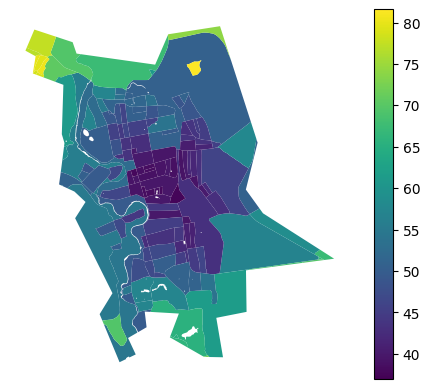

In [27]:
blocks.plot('area_accessibility', legend=True).set_axis_off()

___

## 4. Вычисления **показателей застройки**

Здания определяют параметры городской среды в разных блоках. Для некоторых методов blocksnet может использоваться только население, но в целом здание определяется с помощью:

- `population : float`
- `footprint_area : float` - базовая площадь здания.
- `number_of_floors : float`
- `build_floor_area : float` - суммарная площадь каждого этажа здания
- `is_living : bool`
- `жилая_площадь : float` - площадь, определенная для жителей
- `non_living_area : float` - область, в которой не определено место проживания

Некоторые из этих параметров могут быть отсутствовать в данных, и в этом случае они будут установлены в значение по умолчанию.

### 4.1. Извлечение зданий из OpenStreetMap

Этот шаг можно пропустить, если данные уже получены из любого доступного источника.

In [28]:
buildings = ox.features_from_polygon(boundaries.to_crs(4326).union_all(), tags={'building': True}).reset_index(drop=True).to_crs(crs)

#### 4.1.1. `is_living`

In [29]:
is_living_tags = ['residential', 'house', 'apartments', 'detached', 'terrace', 'dormitory']
buildings['is_living'] = buildings['building'].apply(lambda b : b in is_living_tags)

#### 4.1.2. `number_of_floors`

In [30]:
import pandas as pd

buildings['number_of_floors'] = pd.to_numeric(buildings['building:levels'], errors='coerce')

In [31]:
required = {'site_area', 'footprint_area', 'build_floor_area', 'living_area'}
missing = required - set(buildings.columns)
print(missing)

{'site_area', 'footprint_area', 'living_area', 'build_floor_area'}


### 4.2. **Восполнение** недостающих данных

In [32]:
buildings['number_of_floors'] = buildings['number_of_floors'].clip(lower=1)

In [33]:
from blocksnet.preprocessing.imputing import impute_buildings

buildings = impute_buildings(buildings, default_living_demand=30)

2025-12-09 13:58:04.645 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column footprint_area not found and will be initialized as None
2025-12-09 13:58:04.645 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column build_floor_area not found and will be initialized as None
2025-12-09 13:58:04.646 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column living_area not found and will be initialized as None
2025-12-09 13:58:04.646 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column non_living_area not found and will be initialized as None
2025-12-09 13:58:04.646 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column population not found and will be initialized as None


In [34]:
buildings.sample(5)

,geometry,is_living,number_of_floors,footprint_area,build_floor_area,living_area,non_living_area,population
5358,"POLYGON ((439428.493 5474201.255, 439428.449 5...",True,1.0,128.150255,128.150255,115.335230,12.815026,3.0
4066,"POLYGON ((438034.788 5471450.178, 438034.638 5...",True,1.0,87.212327,87.212327,78.491094,8.721233,2.0
4131,"POLYGON ((439252.041 5475651.945, 439255.343 5...",True,1.0,58.905146,58.905146,53.014631,5.890515,1.0
205,"POLYGON ((438345.484 5473439.712, 438348.155 5...",False,1.0,1895.519489,1895.519489,0.000000,1895.519489,NaN
5580,"POLYGON ((439170.128 5472287.913, 439170.727 5...",True,1.0,108.750709,108.750709,97.875638,10.875071,3.0


In [35]:
buildings.population.sum()

np.float64(12165.0)

### 4.3. Перенос зданий в городские кварталы

In [36]:
from blocksnet.blocks.aggregation import aggregate_objects

buildings_blocks = aggregate_objects(blocks, buildings)[0]

2025-12-09 13:58:08.442 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2025-12-09 13:58:08.447 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects


In [37]:
buildings_blocks.head()

,geometry,is_living,number_of_floors,footprint_area,build_floor_area,living_area,non_living_area,population,count
0,"POLYGON ((442718.951 5471710.302, 442745.301 5...",0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0
1,"POLYGON ((442745.301 5471695.335, 442718.951 5...",0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0
2,"POLYGON ((442580.521 5471789.381, 442718.951 5...",0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0
3,"POLYGON ((442505.529 5471832.217, 442580.521 5...",12.0,138.0,67227.598384,85455.35763,1037.303335,84418.054295,27.0,120.0
4,"POLYGON ((442505.529 5471832.217, 442243.731 5...",0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0


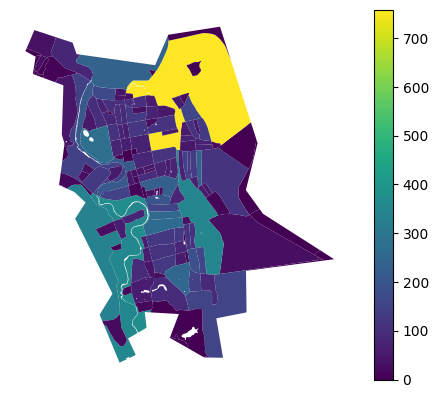

In [38]:
buildings_blocks.plot('population', legend=True).set_axis_off()

In [ ]:
blocks = blocks.join(buildings_blocks.drop(columns=['geometry']))
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,site_area,area_accessibility,is_living,number_of_floors,footprint_area,build_floor_area,living_area,non_living_area,population,count
0,"POLYGON ((442718.951 5471710.302, 442745.301 5...",0.000000,0.0,0.394623,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.394623,3.614726e+04,69.572684,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0
1,"POLYGON ((442745.301 5471695.335, 442718.951 5...",0.000000,0.0,0.039570,0.00000,0.0,0.0,0.906288,LandUse.AGRICULTURE,0.906288,1.309921e+05,67.459394,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0
2,"POLYGON ((442580.521 5471789.381, 442718.951 5...",0.000000,0.0,0.297516,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.297516,9.744864e+03,66.842103,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0
3,"POLYGON ((442505.529 5471832.217, 442580.521 5...",0.000000,0.0,0.040294,0.09687,0.0,0.0,0.492953,LandUse.AGRICULTURE,0.492953,5.067034e+06,56.870491,12.0,138.0,67227.598384,85455.35763,1037.303335,84418.054295,27.0,120.0
4,"POLYGON ((442505.529 5471832.217, 442243.731 5...",0.000000,0.0,0.000000,0.00000,0.0,0.0,0.906280,LandUse.AGRICULTURE,0.906280,9.147270e+05,58.586360,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,"POLYGON ((436542.557 5474507.139, 436580.924 5...",1.000000,0.0,0.000000,0.00000,0.0,0.0,0.000000,LandUse.RESIDENTIAL,1.000000,2.145462e+03,56.137935,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0
153,"POLYGON ((435649.97 5476242.386, 435708.526 54...",0.104557,0.0,0.531830,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.531830,1.470662e+04,78.472808,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0
154,"POLYGON ((435739.162 5476301.666, 435761.925 5...",0.635169,0.0,0.000000,0.00000,0.0,0.0,0.000000,LandUse.RESIDENTIAL,0.635169,1.031716e+05,80.476358,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0
155,"POLYGON ((435906.212 5476228.045, 435922.269 5...",0.069378,0.0,0.456070,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.456070,2.673256e+04,79.040013,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0


_____


## 5. Морфотипы 

### 5.1 Вычисление плотности застройки

In [40]:
from blocksnet.analysis.indicators import calculate_density_indicators 

density_df = calculate_density_indicators(blocks[[
    'site_area',
    'footprint_area',
    'build_floor_area',
    'living_area'
]])
density_df.head()

2025-12-09 13:58:14.290 | WARNING  | blocksnet.analysis.indicators.density.schemas:_before_validate:19 - The non_living_area is not in columns, restoring


,site_area,footprint_area,build_floor_area,living_area,non_living_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,3.614726e+04,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
1,1.309921e+05,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
2,9.744864e+03,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
3,5.067034e+06,67227.598384,85455.35763,1037.303335,84418.054295,0.016865,0.013268,0.012139,1.271135,58.507813,0.01543,1.255705
4,9.147270e+05,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,inf,NaN,NaN


In [41]:
blocks.loc[:, density_df.columns] = density_df
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,non_living_area,population,count,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,"POLYGON ((442718.951 5471710.302, 442745.301 5...",0.0,0.0,0.394623,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.394623,...,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
1,"POLYGON ((442745.301 5471695.335, 442718.951 5...",0.0,0.0,0.039570,0.00000,0.0,0.0,0.906288,LandUse.AGRICULTURE,0.906288,...,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
2,"POLYGON ((442580.521 5471789.381, 442718.951 5...",0.0,0.0,0.297516,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.297516,...,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
3,"POLYGON ((442505.529 5471832.217, 442580.521 5...",0.0,0.0,0.040294,0.09687,0.0,0.0,0.492953,LandUse.AGRICULTURE,0.492953,...,84418.054295,27.0,120.0,0.016865,0.013268,0.012139,1.271135,58.507813,0.01543,1.255705
4,"POLYGON ((442505.529 5471832.217, 442243.731 5...",0.0,0.0,0.000000,0.00000,0.0,0.0,0.906280,LandUse.AGRICULTURE,0.906280,...,0.000000,0.0,0.0,0.000000,0.000000,NaN,NaN,inf,NaN,NaN


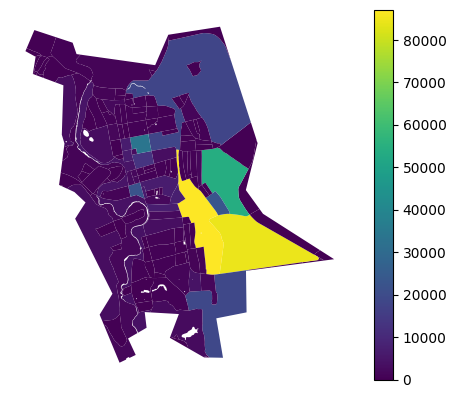

In [107]:
blocks.plot('non_living_area', legend=True).set_axis_off()

### 5.1 Вычисления морфотипов Стрелки

In [ ]:
from blocksnet.analysis.morphotypes import get_strelka_morphotypes

strelka_df = get_strelka_morphotypes(blocks)
blocks.loc[:, strelka_df.columns] = strelka_df
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,population,count,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype
0,"POLYGON ((442718.951 5471710.302, 442745.301 5...",0.0,0.0,0.394623,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.394623,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,inf,NaN,NaN,NaN
1,"POLYGON ((442745.301 5471695.335, 442718.951 5...",0.0,0.0,0.039570,0.00000,0.0,0.0,0.906288,LandUse.AGRICULTURE,0.906288,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,inf,NaN,NaN,NaN
2,"POLYGON ((442580.521 5471789.381, 442718.951 5...",0.0,0.0,0.297516,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.297516,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,inf,NaN,NaN,NaN
3,"POLYGON ((442505.529 5471832.217, 442580.521 5...",0.0,0.0,0.040294,0.09687,0.0,0.0,0.492953,LandUse.AGRICULTURE,0.492953,...,27.0,120.0,0.016865,0.013268,0.012139,1.271135,58.507813,0.01543,1.255705,low-rise non-residential
4,"POLYGON ((442505.529 5471832.217, 442243.731 5...",0.0,0.0,0.000000,0.00000,0.0,0.0,0.906280,LandUse.AGRICULTURE,0.906280,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,inf,NaN,NaN,NaN


# **Urbanomy**

In [43]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = blocks[cols]
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.0,0.0,0.394623,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.394623,0.000000,...,0.000000,0.0,3.614726e+04,0.000000,0.000000,0.000000,0.000000,NaN,69.572684,"POLYGON ((442718.951 5471710.302, 442745.301 5..."
1,0.0,0.0,0.039570,0.00000,0.0,0.0,0.906288,LandUse.AGRICULTURE,0.906288,0.000000,...,0.000000,0.0,1.309921e+05,0.000000,0.000000,0.000000,0.000000,NaN,67.459394,"POLYGON ((442745.301 5471695.335, 442718.951 5..."
2,0.0,0.0,0.297516,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.297516,0.000000,...,0.000000,0.0,9.744864e+03,0.000000,0.000000,0.000000,0.000000,NaN,66.842103,"POLYGON ((442580.521 5471789.381, 442718.951 5..."
3,0.0,0.0,0.040294,0.09687,0.0,0.0,0.492953,LandUse.AGRICULTURE,0.492953,67227.598384,...,84418.054295,27.0,5.067034e+06,0.016865,0.013268,0.012139,1.271135,low-rise non-residential,56.870491,"POLYGON ((442505.529 5471832.217, 442580.521 5..."
4,0.0,0.0,0.000000,0.00000,0.0,0.0,0.906280,LandUse.AGRICULTURE,0.906280,0.000000,...,0.000000,0.0,9.147270e+05,0.000000,0.000000,0.000000,0.000000,NaN,58.586360,"POLYGON ((442505.529 5471832.217, 442243.731 5..."


___

## Предсказание **стоимости земельных участков**

In [ ]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('./data/catboost_model.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=basline_blocks,
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,land_value
0,0.0,0.0,0.394623,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.394623,0.000000,...,0.0,3.614726e+04,0.000000,0.000000,0.000000,0.000000,NaN,69.572684,"POLYGON ((442718.951 5471710.302, 442745.301 5...",2.381443e+07
1,0.0,0.0,0.039570,0.00000,0.0,0.0,0.906288,LandUse.AGRICULTURE,0.906288,0.000000,...,0.0,1.309921e+05,0.000000,0.000000,0.000000,0.000000,NaN,67.459394,"POLYGON ((442745.301 5471695.335, 442718.951 5...",8.583275e+07
2,0.0,0.0,0.297516,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.297516,0.000000,...,0.0,9.744864e+03,0.000000,0.000000,0.000000,0.000000,NaN,66.842103,"POLYGON ((442580.521 5471789.381, 442718.951 5...",6.674832e+06
3,0.0,0.0,0.040294,0.09687,0.0,0.0,0.492953,LandUse.AGRICULTURE,0.492953,67227.598384,...,27.0,5.067034e+06,0.016865,0.013268,0.012139,1.271135,low-rise non-residential,56.870491,"POLYGON ((442505.529 5471832.217, 442580.521 5...",1.332336e+09
4,0.0,0.0,0.000000,0.00000,0.0,0.0,0.906280,LandUse.AGRICULTURE,0.906280,0.000000,...,0.0,9.147270e+05,0.000000,0.000000,0.000000,0.000000,NaN,58.586360,"POLYGON ((442505.529 5471832.217, 442243.731 5...",3.442627e+08


count       155.000000
mean     105702.064978
std       42225.990697
min       13321.973334
25%       70737.574191
50%      101640.845132
75%      137581.936062
max      212520.220205
Name: price_per_sotka, dtype: float64


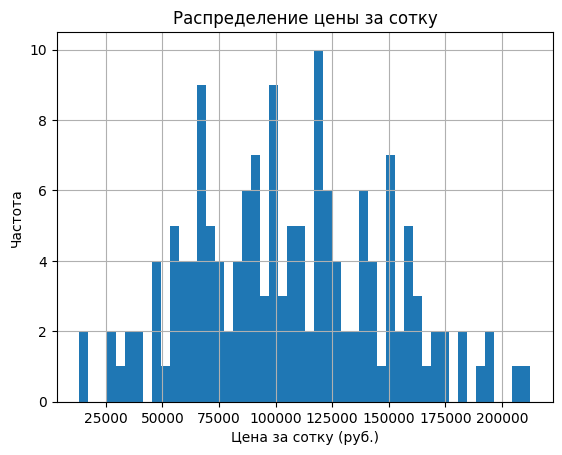

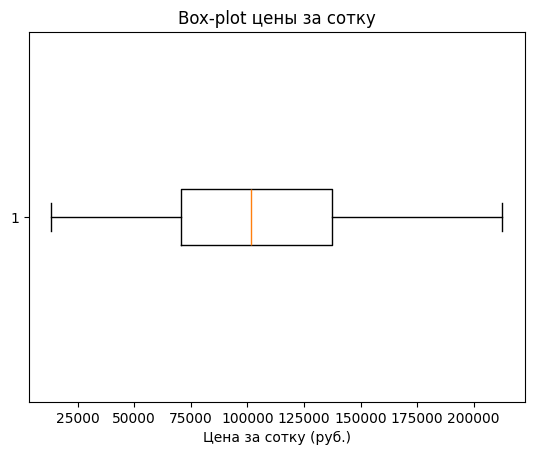

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Цена за сотку (100 м²)
blocks_pred["price_per_sotka"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred["price_per_sotka"] = blocks_pred["price_per_sotka"].replace([np.inf, -np.inf], np.nan)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["price_per_sotka"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["price_per_sotka"] <= p99].copy()

print(blocks_clean["price_per_sotka"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["price_per_sotka"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["price_per_sotka"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()


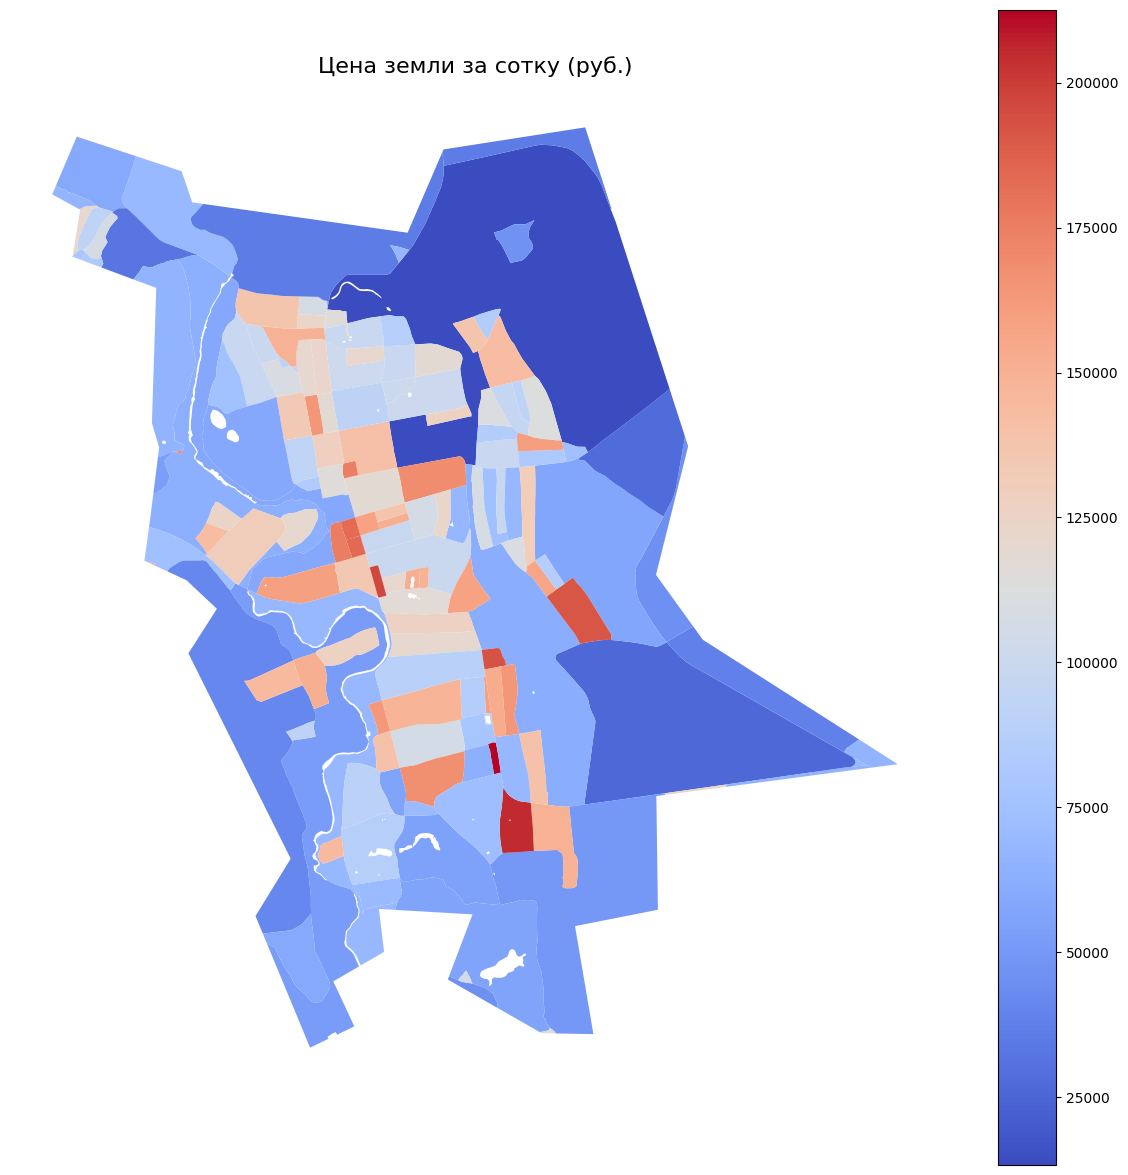

In [109]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='price_per_sotka',
    legend=True,
    figsize=(15,15),
    cmap='coolwarm'
).set_axis_off()
plt.title('Цена земли за сотку (руб.)', fontsize=16)

plt.show()

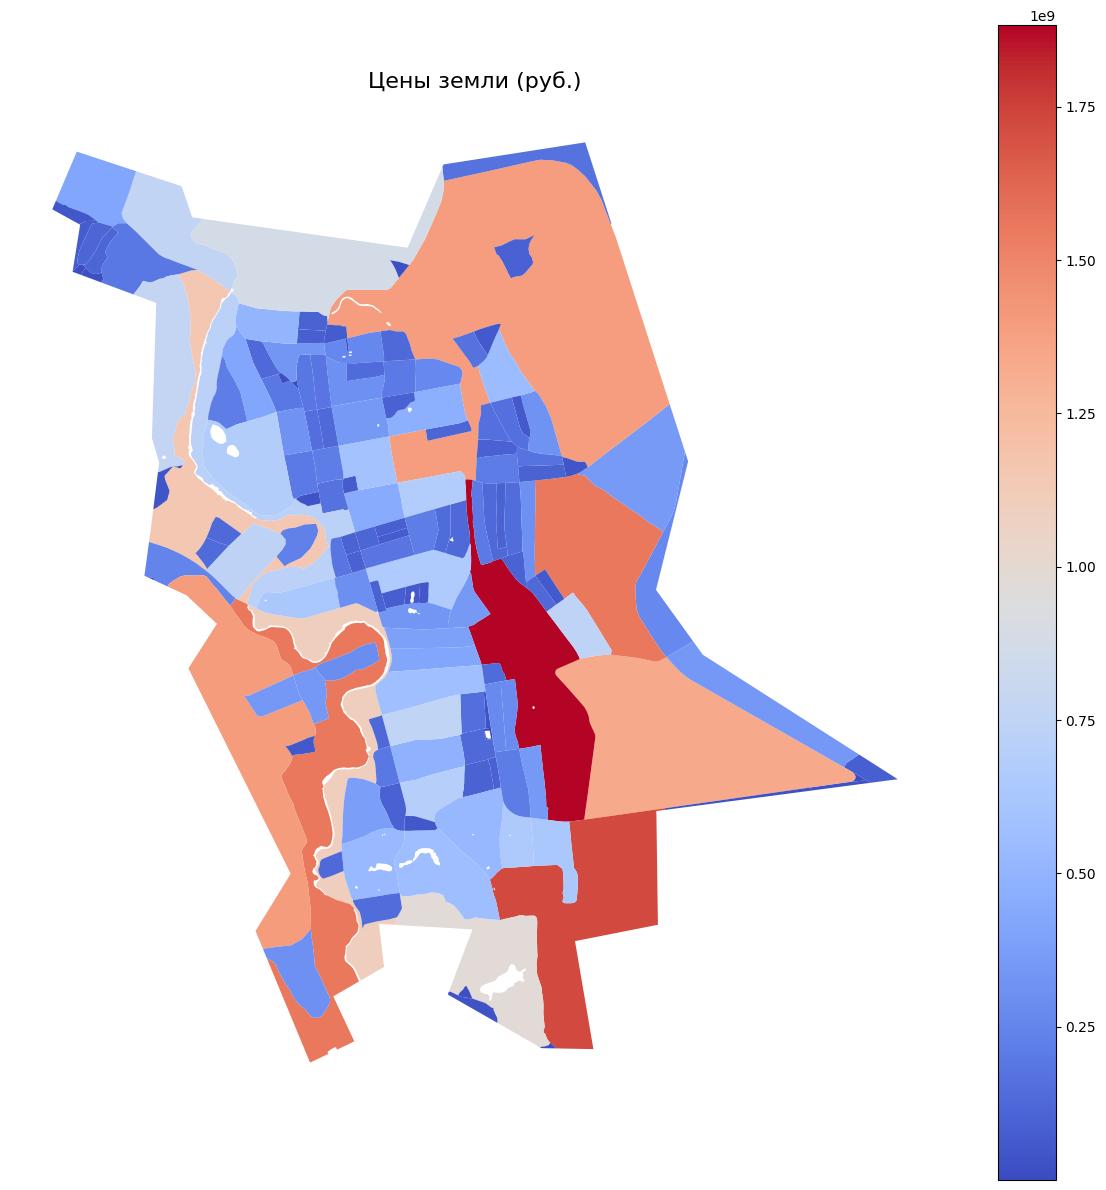

In [110]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(15,15),
    cmap='coolwarm'
).set_axis_off()
plt.title('Цены земли (руб.)', fontsize=16)

plt.show()

## Сценарное изменение земельных участков

In [ ]:
blocks_clean["id"] = blocks_clean.index


In [70]:
blocks_clean.loc[16]

residential                                                         1.0
business                                                            0.0
recreation                                                          0.0
industrial                                                          0.0
transport                                                           0.0
special                                                             0.0
agriculture                                                         0.0
land_use                                            LandUse.RESIDENTIAL
share                                                               1.0
footprint_area                                             16555.886818
build_floor_area                                           16555.886818
living_area                                                 3367.258144
non_living_area                                            13188.628674
population                                                      

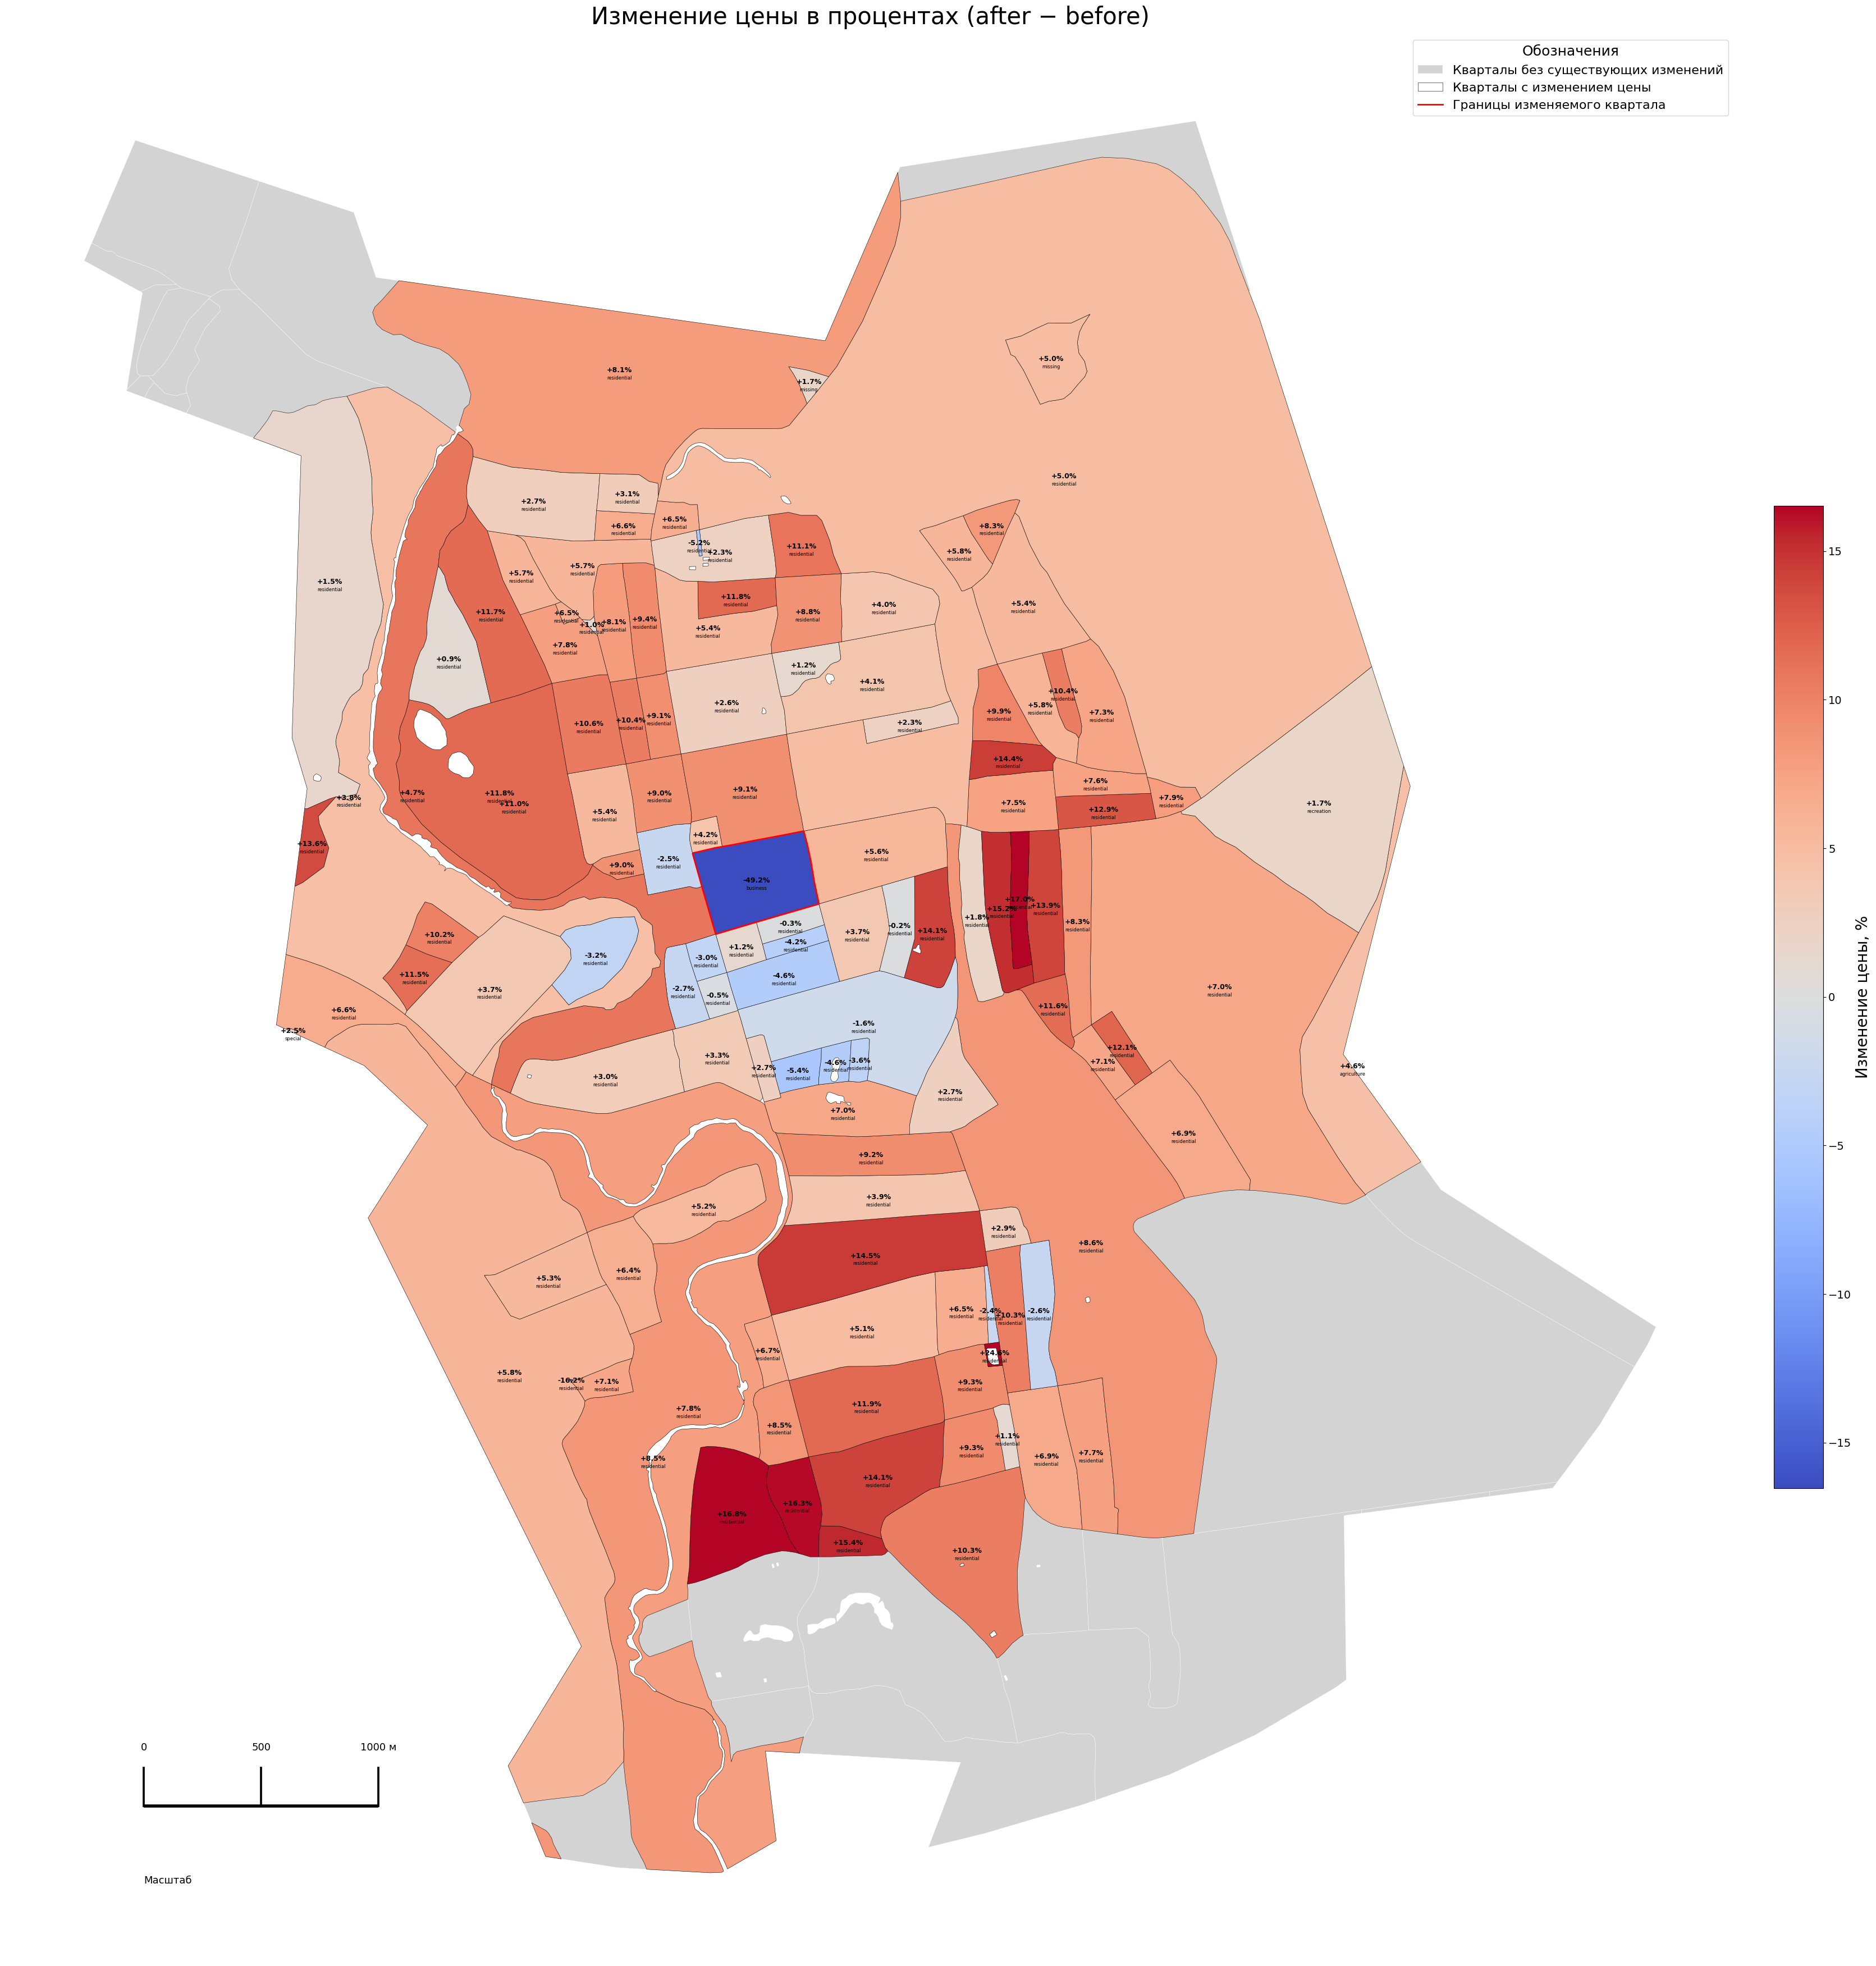


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
16 | business | 453 206 352 ₽ → 230 368 925 ₽ | -222 837 427 ₽ | -49.2%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
34 | residential | 1 542 870 843 ₽ → 1 673 367 928 ₽ | +130 497 086 ₽ | +8.5%
120 | residential | 367 467 235 ₽ → 429 019 706 ₽ | +61 552 470 ₽ | +16.8%
118 | residential | 92 946 127 ₽ → 108 107 396 ₽ | +15 161 269 ₽ | +16.3%
31 | residential | 1 098 788 632 ₽ → 1 184 539 864 ₽ | +85 751 232 ₽ | +7.8%
122 | residential | 197 529 373 ₽ → 214 389 130 ₽ | +16 859 757 ₽ | +8.5%
123 | residential | 121 311 536 ₽ → 129 486 376 ₽ | +8 174 840 ₽ | +6.7%
124 | residential | 343 677 462 ₽ → 365 816 674 ₽ | +22 139 212 ₽ | +6.4%
96 | residential | 1 394 995 359 ₽ → 1 475 353 612 ₽ | +80 358 253 ₽ | +5.8%
111 | residential | 29 164 ₽ → 24 452 ₽ | -4 713 ₽ | -

In [146]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks_clean
changes = {
    # Функциональное назначение
    'land_use': 'LandUse.BUSINESS',
    'residential': 0.0,
    'business': 1.0,
    'recreation': 0.0,
    'industrial': 0.0,
    'transport': 0.0,
    'special': 0.0,
    'agriculture': 0.0,
    'share': 1.0,

    # Морфология и площади
    'footprint_area': 20_000.0,
    'build_floor_area': 40_000.0,
    'living_area': 0.0,
    'non_living_area': 30_000.0,

    # Плотности (обновляем по формулам)
    'fsi': 0.7942,
    'gsi': 0.0529,
    'mxi': 0.0,

    # Население
    'population': 0.0,

    # Морфотип
    'morphotype': 'high-rise non-residential',
}
target_idx = 16

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
    figsize=(35, 40),
)

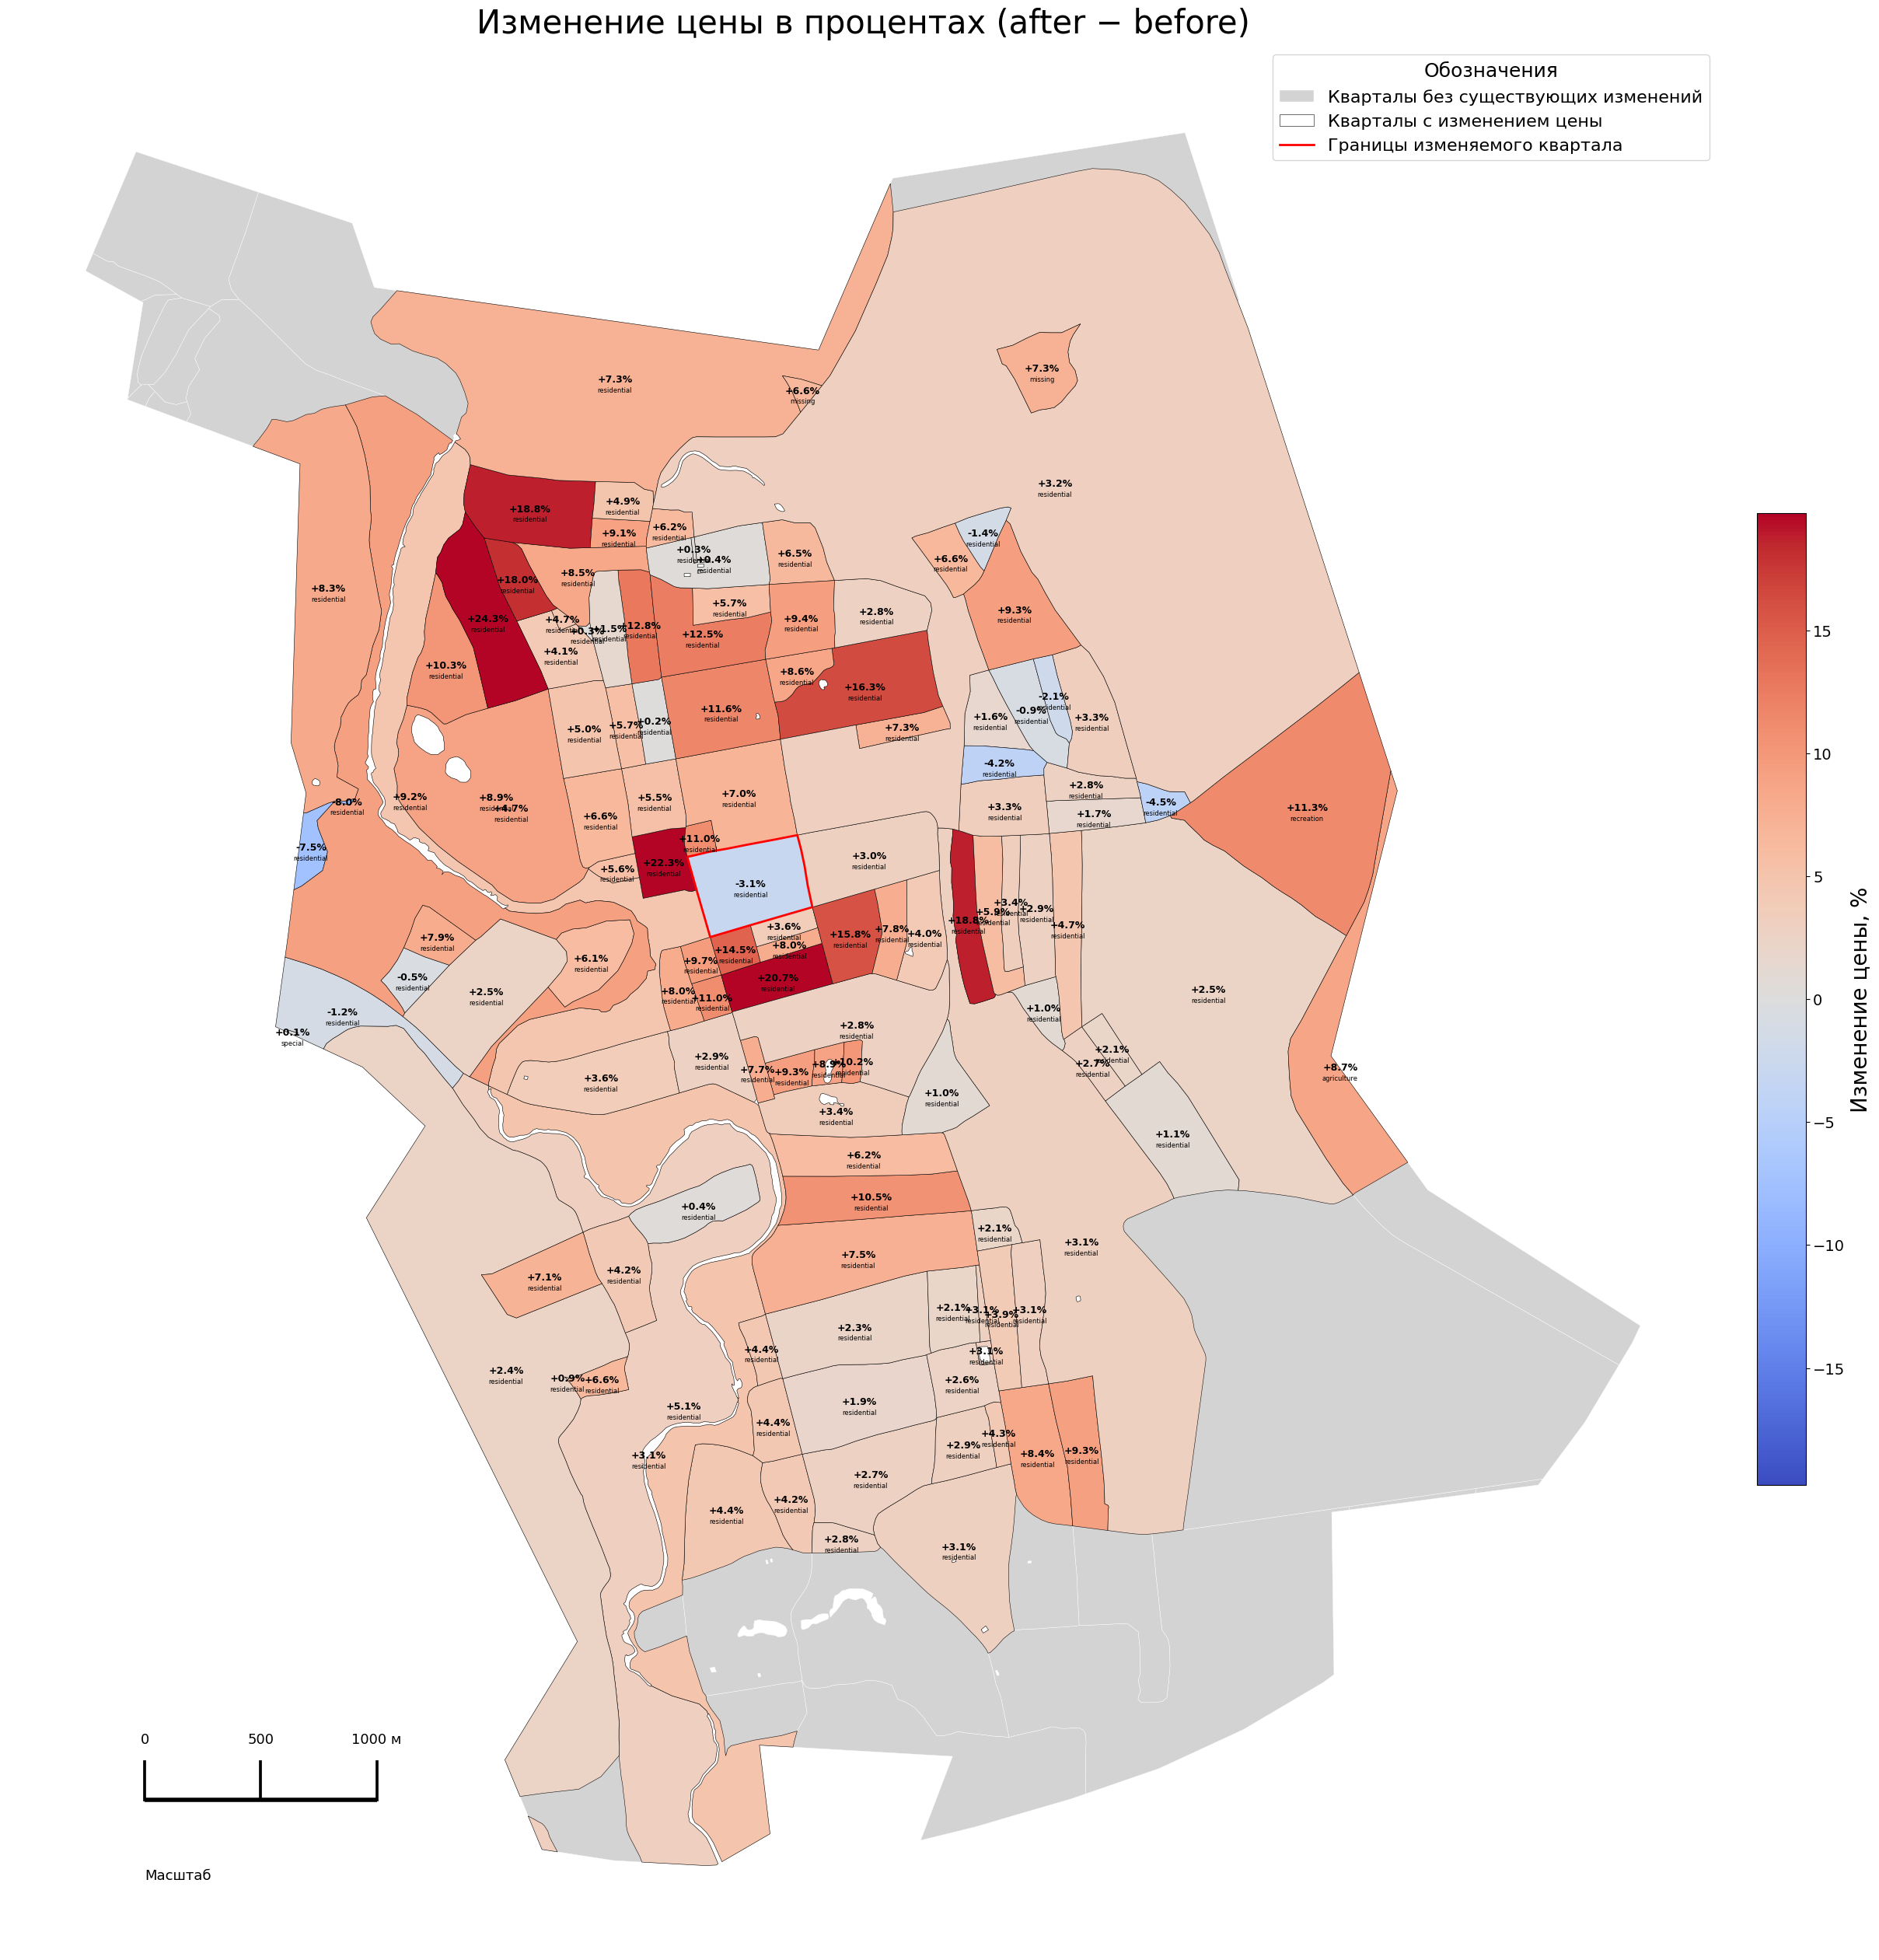


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
16 | residential | 453 206 352 ₽ → 439 221 213 ₽ | -13 985 139 ₽ | -3.1%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
34 | residential | 1 542 870 843 ₽ → 1 591 425 736 ₽ | +48 554 893 ₽ | +3.1%
120 | residential | 367 467 235 ₽ → 383 610 105 ₽ | +16 142 869 ₽ | +4.4%
118 | residential | 92 946 127 ₽ → 96 860 778 ₽ | +3 914 651 ₽ | +4.2%
31 | residential | 1 098 788 632 ₽ → 1 154 381 450 ₽ | +55 592 818 ₽ | +5.1%
122 | residential | 197 529 373 ₽ → 206 288 070 ₽ | +8 758 697 ₽ | +4.4%
123 | residential | 121 311 536 ₽ → 126 690 640 ₽ | +5 379 104 ₽ | +4.4%
124 | residential | 343 677 462 ₽ → 358 025 264 ₽ | +14 347 802 ₽ | +4.2%
96 | residential | 1 394 995 359 ₽ → 1 428 023 961 ₽ | +33 028 601 ₽ | +2.4%
111 | residential | 29 164 ₽ → 29 419 ₽ | +254 ₽ | +0.9%
11

In [154]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks_clean
changes = {
    # Функциональное назначение — остаётся жилым
    'land_use': 'LandUse.RESIDENTIAL',
    'residential': 1.0,
    'business': 0.0,
    'recreation': 0.0,
    'industrial': 0.0,
    'transport': 0.0,
    'special': 0.0,
    'agriculture': 0.0,
    'share': 1.0,

    # Дополнительный дом
    'footprint_area': 16555.886818 + 1500.0,      
    'build_floor_area': 16555.886818 + 10800.0,   
    'living_area': 3367.258144 + 8100.0,
    'non_living_area': 13188.628674 + (10800.0 - 8100.0),

    # Новое население
    'population': 80.0 + 300.0,

    # Обновлённые плотности
    # fsi = BFA / site_area
    'fsi': (16555.886818 + 10800.0) / 377730.418579,
    # gsi = footprint / site_area
    'gsi': (16555.886818 + 1200.0) / 377730.418579,
    # mxi = living / build_floor_area
    'mxi': (3367.258144 + 8100.0) / (16555.886818 + 10800.0),

    'morphotype': 'individual residential',
}

target_idx = 16

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
    figsize=(25, 40),
)

In [156]:
blocks_after = blocks_after.copy()
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_idx, "is_project"] = True
manual_land_value_before = 193121167
blocks_after.at[target_idx, "land_value_before"] = manual_land_value_before


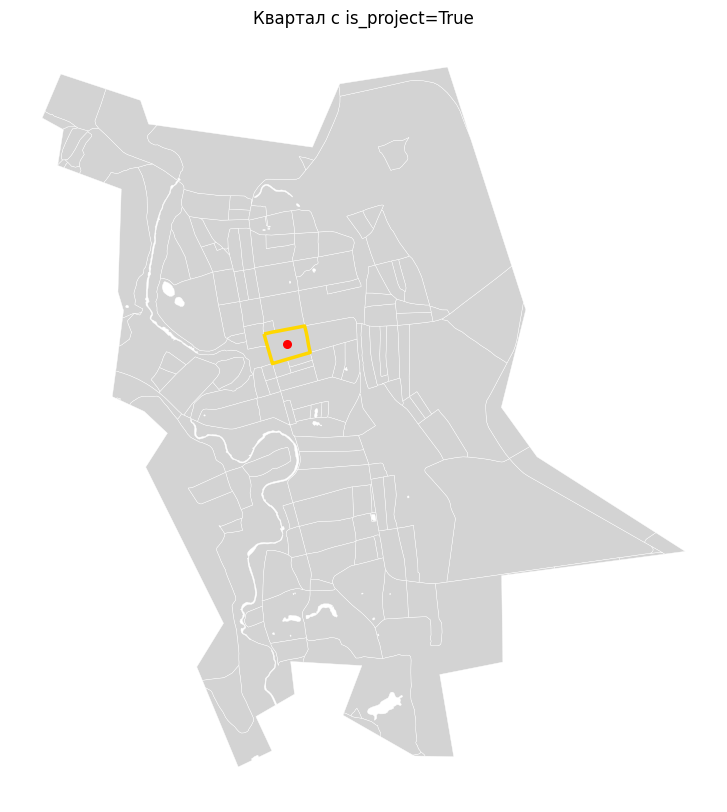

In [157]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
blocks_after.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.3)  # фон
blocks_after.loc[blocks_after["is_project"]].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=2.5
)
blocks_after.loc[blocks_after["is_project"]].centroid.plot(
    ax=ax, color="red", markersize=30, zorder=3
)

ax.set_title("Квартал с is_project=True")
ax.axis("off")
plt.show()

# **Инвестиционная** привлекактельтность 

In [158]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 120_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_300,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 4_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 6_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}

In [159]:
from urbanomy.methods.investment_potential import prepare_investment_input


potential_df = pd.read_csv("./data/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = blocks_after,
    project_potential = potential_df,
)

investment_input.head()

,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential
0,LandUse.RESIDENTIAL,4.450964e+08,193121167.0,377730.418579,11467.258144,15888.628674,27355.886818,1.0,4.0


In [160]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          377,730.42
 • Built area:         27,355.89
 • Land value:         445,096,374.18
 • Construction cost:  1,231,014,906.81
 • Investment need:    1,676,111,280.99
 • Spatial potential:  4.00
 • Project NPV:        176,629,196.44
 • Project IRR:        0.22
 • Project ROI:        2.80
 • Project PP (yrs):   5.62
 • Project EI:         52.48
 • Project INV score:  30.74


,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RESIDENTIAL,377730.42,193121167.0,27355.89,4.450964e+08,1.231015e+09,1.676111e+09,1.766292e+08,0.22,2.8,5.62,52.48,4.0,30.74


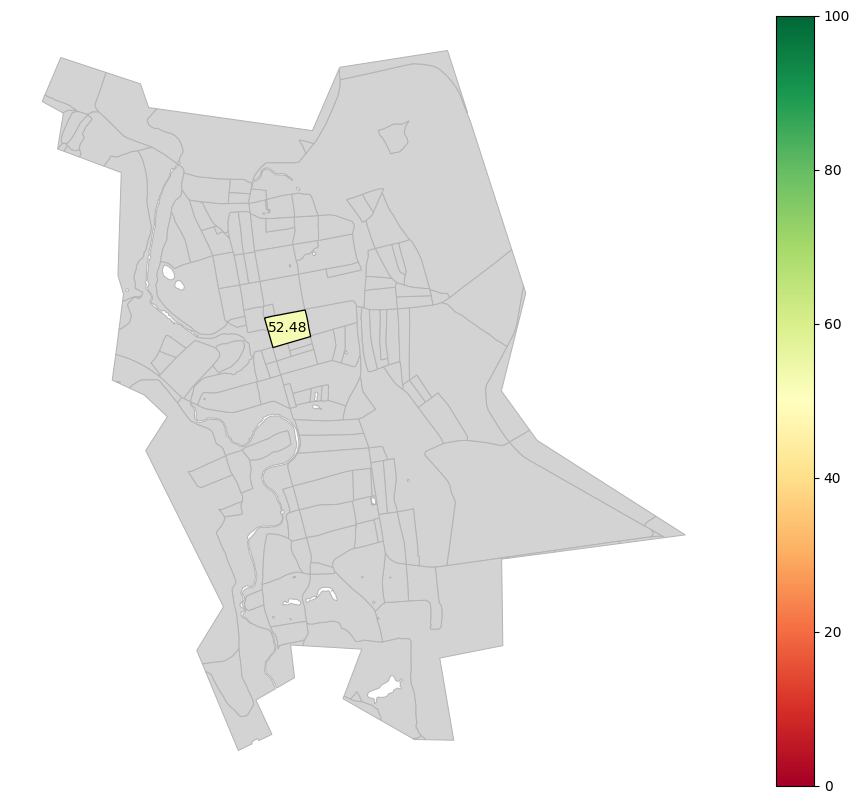

In [161]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "EI"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(15, 10))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()


In [162]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 600_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,2 052
1,Валовый региональный продукт на душу населения,1 014
2,Доходы бюджета территории,517 728 352
3,Средний уровень заработной платы,0.0000
4,Износ основного фонда (тыс. руб.),35 084
